# Regression Project

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statistics  as s
from scipy import stats

In [2]:
new_df = pd.read_csv('new_df.csv')
n_df = new_df.drop(['cluster','Unnamed: 0','user_type'],axis=1)
n_df.head()

,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,sleep_efficiency,mental_health_score,addiction_score,usage_per_sleep,new_age
0,0,3.8,6.5,1.7,2.77,1.2,1,6,6,2,3.823529,12,6.46,0.584615,0
1,0,6.5,5.8,0.6,2.57,0.2,2,9,7,0,9.666667,16,3.90,1.120690,0
2,1,2.9,7.0,1.2,3.04,1.7,0,3,2,1,5.833333,5,3.48,0.414286,0
3,1,7.9,5.0,1.6,2.21,1.2,2,10,8,2,3.125000,18,12.64,1.580000,0
4,1,1.2,8.8,0.9,3.61,1.9,0,1,2,1,9.777779,3,1.08,0.136364,1


In [3]:
n_df['wellness_score'] = (
    n_df['sleep_hours'] +
    n_df['physical_activity'] -
    n_df['stress_level']
)

In [4]:
targets = [
    'stress_level',
    'anxiety_level',
    'wellness_score',
    'mental_health_score'
]

In [5]:
features = [
    'daily_social_media_hours',
    'sleep_hours',
    'screen_time_before_sleep',
    'academic_performance',
    'physical_activity',
    'social_interaction_level',
    'depression_risk',
    # 'user_type',
    'sleep_efficiency',
    'addiction_score',
    'usage_per_sleep'
]

In [6]:
n_df.head()

,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,sleep_efficiency,mental_health_score,addiction_score,usage_per_sleep,new_age,wellness_score
0,0,3.8,6.5,1.7,2.77,1.2,1,6,6,2,3.823529,12,6.46,0.584615,0,1.7
1,0,6.5,5.8,0.6,2.57,0.2,2,9,7,0,9.666667,16,3.90,1.120690,0,-3.0
2,1,2.9,7.0,1.2,3.04,1.7,0,3,2,1,5.833333,5,3.48,0.414286,0,5.7
3,1,7.9,5.0,1.6,2.21,1.2,2,10,8,2,3.125000,18,12.64,1.580000,0,-3.8
4,1,1.2,8.8,0.9,3.61,1.9,0,1,2,1,9.777779,3,1.08,0.136364,1,9.7


In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [8]:
# X = n_df.drop(['anxiety_level'],axis=1) # 'platform_usage_Both','platform_usage_Instagram','platform_usage_Other','platform_usage_TikTok'
# y = n_df['anxiety_level']

In [9]:
def calculate_vif(data):
  vif = pd.DataFrame()
  vif['Feature'] = data.columns
  vif['vif_score'] = [variance_inflation_factor(data.values,i) for i in range(len(data.columns))]
  return vif

In [10]:
# # Assuming 'X' is your DataFrame containing only the independent variables
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns

    # Calculate VIF for each feature
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif_data

In [11]:
calculate_vif(n_df[features])

,Feature,VIF
0,daily_social_media_hours,146.132732
1,sleep_hours,189.411279
2,screen_time_before_sleep,54.315140
3,academic_performance,142.979406
4,physical_activity,4.474092
5,social_interaction_level,2.489025
6,depression_risk,3.365977
7,sleep_efficiency,18.007031
8,addiction_score,40.438952
9,usage_per_sleep,122.081580


<Axes: xlabel='gender'>

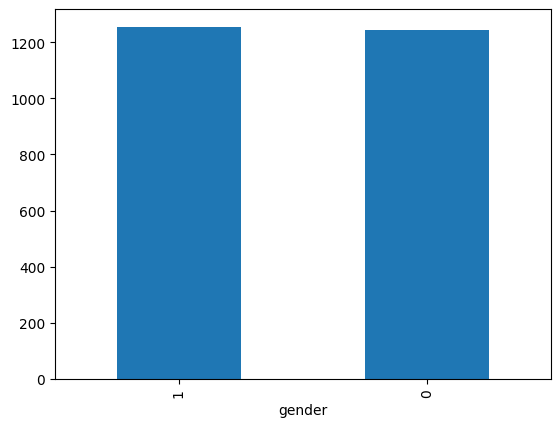

In [12]:
n_df.gender.value_counts().plot(kind='bar')

In [13]:
# Intuition of VIF

# If one feature can be predicted very well using other features:

# R2→1

# then:

# VIF → ∞

# Meaning:

# ⚠️ High multicollinearity

# VIF Interpretation Table

| VIF Value | Meaning                |
| --------- | ---------------------- |
| 1         | No correlation         |
| 1 - 5     | Moderate correlation   |
| > 5       | High multicollinearity |
| > 10      | Serious problem        |


In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

| Metric         | Meaning                    |   |         |
| -------------- | -------------------------- | - | ------- |
| R-squared      | Model performance          |   |         |
| Adj. R-squared | Adjusted performance       |   |         |
| coef           | Feature impact             |   |         |
| std err        | Standard error             |   |         |
| t              | t-statistic                |   |         |
| P>             | t                          |   | p-value |
| F-statistic    | Overall model significance |   |         |


| p-value | Meaning         |
| ------- | --------------- |
| < 0.05  | Significant     |
| > 0.05  | Not significant |


In [15]:
# Add constant
X1 = sm.add_constant(n_df[features])
for i in targets:
    # print(i)
    model = sm.OLS(n_df[i], X1).fit()
    print(model.summary())

# print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           stress_level   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     3511.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:58:55   Log-Likelihood:                -2931.9
No. Observations:                2500   AIC:                             5886.
Df Residuals:                    2489   BIC:                             5950.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

# 🔥 Multi-Output Regression

In [92]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
# Stacking and Voting :-
from sklearn.ensemble import StackingRegressor,VotingRegressor
from sklearn.linear_model import LogisticRegression , LinearRegression

In [93]:

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [94]:
def calculate_adjusted_r2(y_true, y_pred, X):
    # Calculate regular R-squared
    r2 = r2_score(y_true, y_pred)

    # Define n (observations) and k (independent variables)
    n = X.shape[0]
    k = X.shape[1]  # p = k

    # Calculate Adjusted R-squared
    adj_r2 = 1 - ((1 - r2) * (n - 1)) / (n - k - 1)  # p = k

    return adj_r2

In [95]:
def evaluation_model(model,X_train,X_test,y_train,y_test):
    y_pred = model.predict(X_test)
    print(f"Training Score :- { model.score(X_train,y_train) * 100 }")
    print(f"Testing Score :- { model.score(X_test,y_test) * 100 }")      
    print(f"R^2 Score:- {r2_score(y_test,y_pred) * 100}")
    print(f" Mean Absolute Error :- {mean_absolute_error(y_test,y_pred) * 100} ")
    print(f" Mean Squared Error :- {mean_squared_error(y_test,y_pred) * 100}")
    print(f" Root Mean Squared Error :- {np.sqrt(mean_squared_error(y_test,y_pred) * 100)}")
    print(f" Adjusted R^2 Score: - {calculate_adjusted_r2(y_test, y_pred, X_test) * 100}")
    # print(model.score(X_train,y_train) * 100)
    # print(model.score(X_test,y_test) * 100)
    
    sns.distplot(y_test-y_pred)  # Actual - Prediciton  Mental health Score
    plt.show()
    
    sns.distplot(y_test)  # Actual Mental health Score
    plt.show()
    
    sns.distplot(y_pred) # Prediction Mental health Score
    plt.show()
    
    sns.scatterplot(x=y_test,y=y_pred)
    plt.show()

In [96]:
model = RandomForestRegressor(n_estimators=300,random_state=41)
model

RandomForestRegressor(n_estimators=300, random_state=41)

In [97]:
X = n_df[features]

In [98]:
X.head()

,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,depression_risk,sleep_efficiency,addiction_score,usage_per_sleep
0,3.8,6.5,1.7,2.77,1.2,1,2,3.823529,6.46,0.584615
1,6.5,5.8,0.6,2.57,0.2,2,0,9.666667,3.90,1.120690
2,2.9,7.0,1.2,3.04,1.7,0,1,5.833333,3.48,0.414286
3,7.9,5.0,1.6,2.21,1.2,2,2,3.125000,12.64,1.580000
4,1.2,8.8,0.9,3.61,1.9,0,1,9.777779,1.08,0.136364


RandomForestRegressor(n_estimators=300, random_state=41)
                    Feature  Importance
3      academic_performance    0.844153
9           usage_per_sleep    0.058134
0  daily_social_media_hours    0.027941
6           depression_risk    0.026862
4         physical_activity    0.020299
1               sleep_hours    0.006444
8           addiction_score    0.005947
7          sleep_efficiency    0.005163
2  screen_time_before_sleep    0.003052
5  social_interaction_level    0.002005


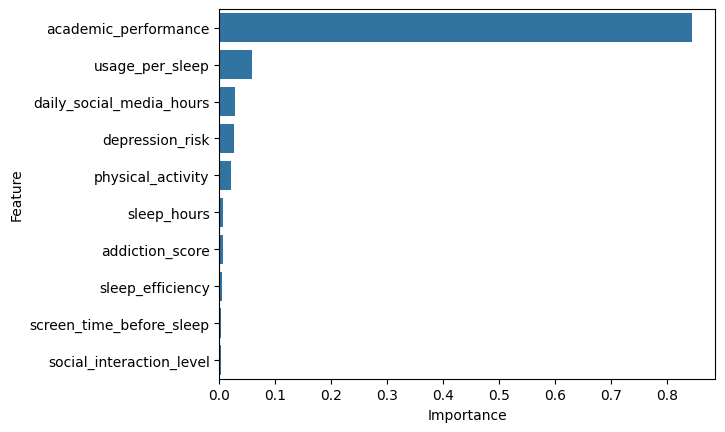

RandomForestRegressor(n_estimators=300, random_state=41)
                    Feature  Importance
3      academic_performance    0.754385
9           usage_per_sleep    0.097008
0  daily_social_media_hours    0.035903
4         physical_activity    0.027492
6           depression_risk    0.022655
8           addiction_score    0.017106
7          sleep_efficiency    0.016069
1               sleep_hours    0.014832
2  screen_time_before_sleep    0.008859
5  social_interaction_level    0.005692


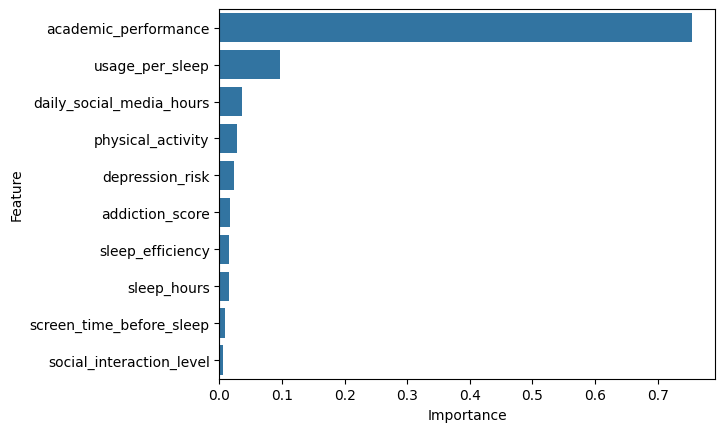

RandomForestRegressor(n_estimators=300, random_state=41)
                    Feature  Importance
3      academic_performance    0.838104
9           usage_per_sleep    0.064839
4         physical_activity    0.043730
6           depression_risk    0.019415
1               sleep_hours    0.019382
8           addiction_score    0.004241
0  daily_social_media_hours    0.003958
7          sleep_efficiency    0.003200
2  screen_time_before_sleep    0.001794
5  social_interaction_level    0.001338


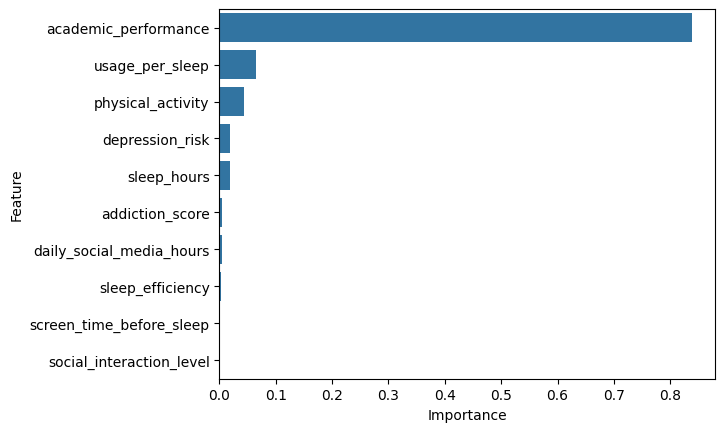

RandomForestRegressor(n_estimators=300, random_state=41)
                    Feature  Importance
3      academic_performance    0.826935
9           usage_per_sleep    0.065509
0  daily_social_media_hours    0.028865
6           depression_risk    0.025407
4         physical_activity    0.021309
8           addiction_score    0.008412
1               sleep_hours    0.008305
7          sleep_efficiency    0.007882
2  screen_time_before_sleep    0.004379
5  social_interaction_level    0.002998


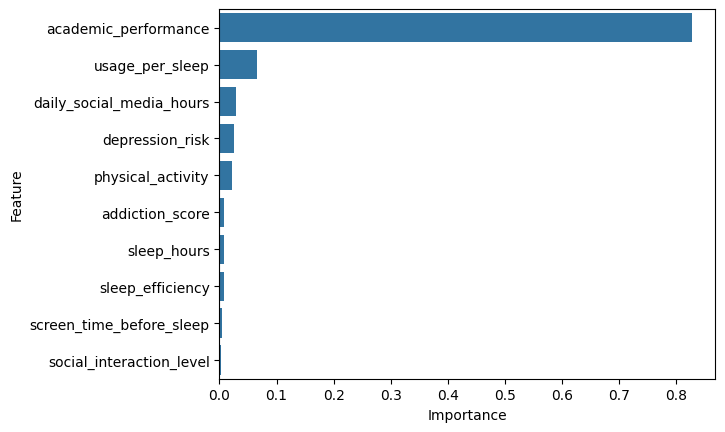

In [39]:
for i in targets:
    # print(i)
    # n_df[i]
    print(model.fit(X,n_df[i]))

    importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

    print(importance.sort_values(
    by='Importance',
    ascending=False
))
    sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.sort_values(
        by='Importance',
        ascending=False
    ))
    plt.show()

   

In [99]:
calculate_vif(X)

,Feature,VIF
0,daily_social_media_hours,146.132732
1,sleep_hours,189.411279
2,screen_time_before_sleep,54.315140
3,academic_performance,142.979406
4,physical_activity,4.474092
5,social_interaction_level,2.489025
6,depression_risk,3.365977
7,sleep_efficiency,18.007031
8,addiction_score,40.438952
9,usage_per_sleep,122.081580


In [47]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.linear_model import Lasso

# param_dist = {'alpha': [0.1, 1.0, 10.0, 100.0]}
# lasso = Lasso()
# random_search = RandomizedSearchCV(lasso, param_dist, n_iter=10, cv=5)
# random_search.fit(X_train, y_train)

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.linear_model import Ridge

# param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
# ridge = Ridge()
# grid_search = GridSearchCV(ridge, param_grid, cv=5)
# grid_search.fit(X_train, y_train)
# grid_search.best_param_, gird_search.best_score_

In [ ]:
# # Split the data
# X_train, X_test, y_train, y_test = train_test_split(
#     X, Y, test_size=0.2, random_state=0)

# model = LinearRegression()
# model.fit(X_train, y_train)


# predictions = model.predict(X_test)

# #Accuracy of the model
# print(r2_score(y_test, predictions)*100)

# model.get_params()

# param_space = {'copy_X': [True,False], 
#                'fit_intercept': [True,False], 
#                'n_jobs': [1,5,10,15,None], 
#                'positive': [True,False]}

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# import pandas as pd 
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score 
# from sklearn.model_selection import train_test_split

# dataset_url = "https://media.geeksforgeeks.org/%5C
# wp-content/uploads/20240617221743/cars.csv"
# df_cars = pd.read_csv(dataset_url)

# # Independent variables
# X = df_cars[["Year", "Kilometers_Driven", "Mileage", 
#              "Engine", "Power", "Seats"]]

# # Dependent variable
# Y = df_cars["Price"]

# # Split the data
# X_train, X_test, y_train, y_test = train_test_split(
#     X, Y, test_size=0.2, random_state=0)

# model = LinearRegression()

# param_space = {'copy_X': [True,False], 
#                'fit_intercept': [True,False], 
#                'n_jobs': [1,5,10,15,None], 
#                'positive': [True,False]}

# random_search = RandomizedSearchCV(model, param_space, n_iter=100, cv=5)
# random_search.fit(X_train, y_train)

# # Parameter which gives the best results
# print(f"Best Hyperparameters: {random_search.best_params_}")

# # Accuracy of the model after using best parameters
# print(f"Best Score: {random_search.best_score_}")

In [ ]:
# from sklearn.model_selection import GridSearchCV
# import pandas as pd 
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score 
# from sklearn.model_selection import train_test_split

# dataset_url = "https://media.geeksforgeeks.org/%5C
# wp-content/uploads/20240617221743/cars.csv"
# df_cars = pd.read_csv(dataset_url)

# # Independent variables
# X = df_cars[["Year", "Kilometers_Driven", "Mileage", 
#              "Engine", "Power", "Seats"]]

# # Dependent variable
# Y = df_cars["Price"]

# # Split the data
# X_train, X_test, y_train, y_test = train_test_split(
#     X, Y, test_size=0.2, random_state=0)

# model = LinearRegression()


# param_space = {'copy_X': [True,False], 'fit_intercept': [True,False], 
#                'n_jobs': [1,5,10,15,None], 'positive': [True,False]}
# grid_search = GridSearchCV(model, param_space, cv=5)

# grid_search.fit(X_train, y_train)

# # Parameter which gives the best results
# print(f"Best Hyperparameters: {grid_search.best_params_}")

# # Accuracy of the model after using best parameters
# print(f"Best Score: {grid_search.best_score_}")

In [100]:
targets

['stress_level', 'anxiety_level', 'wellness_score', 'mental_health_score']

In [101]:
y =n_df[targets]

In [103]:
y.head()

,stress_level,anxiety_level,wellness_score,mental_health_score
0,6,6,1.7,12
1,9,7,-3.0,16
2,3,2,5.7,5
3,10,8,-3.8,18
4,1,2,9.7,3


In [102]:
# X_train,X_test,y_train,y_test = train_test_split(X,n_df['stress_level',test_size=0.2, random_state=6)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=6)

In [104]:
X_train.shape,y_train.shape

((2000, 10), (2000, 4))

In [105]:
X_test.shape,y_test.shape

((500, 10), (500, 4))

# Regression Hyperparameter Tuning

In [ ]:
# stress_level
# anxiety_level
# wellness_score
# mental_health_score
# addiction_score

In [106]:
#Random Forest Regressor
rf_reg_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [107]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf_reg = RandomForestRegressor(random_state=42)

search = RandomizedSearchCV(
    rf_reg,
    rf_reg_params,
    cv=5,
    scoring="r2",
    n_iter=30,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_score_) 
print(search.best_params_)

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


0.914574316949742
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 15}


In [ ]:
# 0.914574316949742
# {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 15}

In [114]:
# XGBoost Regressor
xgb_reg_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "l1":[0.01,0.02,0.03,0.04,0.05],
    "l2":[0.01,0.02,0.03,0.04,0.05]
}

In [115]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(random_state=42)

search = RandomizedSearchCV(
    xgb_reg,
    xgb_reg_params,
    cv=5,
    scoring="r2",
    n_iter=50,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print(search.best_score_) 
print(search.best_params_)

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:14:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "l1", "l2" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.9179633855819702
{'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'l2': 0.02, 'l1': 0.05, 'colsample_bytree': 1.0}


In [ ]:
# 0.9181909441947937
# {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

# {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'l2': 0.02, 'l1': 0.05, 'colsample_bytree': 1.0}

In [116]:
# Linear Regression Regression 
lr_model = MultiOutputRegressor(
         LinearRegression(copy_X=True,fit_intercept=True,n_jobs=-1,positive=True)
)

In [117]:
# Random Forest
rf_model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=300,
        min_samples_split = 10,
        min_samples_leaf =  4,
        max_depth = 15,
        random_state=42
    )
)


#{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 15}
#{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 15}

In [118]:
# Gradient Boosting
gb_model = MultiOutputRegressor(
    GradientBoostingRegressor(
        random_state=42
    )
)

In [119]:
# {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

In [121]:
# XGBoost
xgb_model = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=500,
        #learning_rate=0.05,
        max_depth=3,
        learning_rate=0.01,
        random_state=42,
        subsample=0.7,
        colsample_bytree= 1.0,
        l2=0.02,
        l1 = 0.05
    )
)

# 🔥 Regression Evaluation

In [122]:
models = {
    "lr_model":lr_model,
    "rf_model":rf_model,
    "gb_model":gb_model,
    "xgb_model":xgb_model
}
       
    

In [123]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [124]:
targets

['stress_level', 'anxiety_level', 'wellness_score', 'mental_health_score']

In [125]:
y =n_df[targets]

In [126]:
# X_train,X_test,y_train,y_test = train_test_split(X,n_df['stress_level',test_size=0.2, random_state=6)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=6)

In [127]:
X_train.shape,y_train.shape

((2000, 10), (2000, 4))

In [128]:
X_test.shape,y_train.shape

((500, 10), (2000, 4))

In [129]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = (
        mean_squared_error(
            y_test,
            pred
        )
    ) ** 0.5

    r2 = r2_score(
        y_test,
        pred
    )
    adjusted_r2 = calculate_adjusted_r2(y_test,pred,X_train)

    results.append({
        "Model": name,
        "MAE": mae ,
        "RMSE": rmse ,
        "R2": r2,
        "Adjusted_R2":adjusted_r2
    })

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:17:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "l1", "l2" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:17:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "l1", "l2" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:17:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "l1", "l2" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:17:49] WARNING: C:\actions-runner\_work\xgboost\xgboost

In [130]:
results

[{'Model': 'lr_model',
  'MAE': np.float64(1.1414329702111747),
  'RMSE': np.float64(1.5541663616501786),
  'R2': 0.8573662204554885,
  'Adjusted_R2': 0.8566491074361596},
 {'Model': 'rf_model',
  'MAE': np.float64(0.8344494146461221),
  'RMSE': np.float64(1.1512924742274973),
  'R2': 0.9181386866372634,
  'Adjusted_R2': 0.9177271164343336},
 {'Model': 'gb_model',
  'MAE': np.float64(0.8295823930222075),
  'RMSE': np.float64(1.138386873967656),
  'R2': 0.9201558781066972,
  'Adjusted_R2': 0.9197544496406675},
 {'Model': 'xgb_model',
  'MAE': np.float64(0.8378652042427566),
  'RMSE': np.float64(1.1424954100709157),
  'R2': 0.9197834730148315,
  'Adjusted_R2': 0.9193801722255648}]

In [133]:
final_model = xgb_model

In [134]:
final_model.fit(X_train,y_train)

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:19:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "l1", "l2" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:19:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "l1", "l2" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:20:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "l1", "l2" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:20:01] WARNING: C:\actions-runner\_work\xgboost\xgboost

MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=1.0, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            l1=0.05, l2=0.02,
                                            learning_rate=0.01, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=500, ...))

In [135]:
y_pred = final_model.predict(X_test)
y_pred

array([[ 7.3633924 ,  7.1208344 , -0.1800498 , 14.569862  ],
       [ 9.6887245 ,  9.083535  , -3.3941624 , 18.79634   ],
       [ 8.654062  ,  8.037695  , -0.6444689 , 16.683893  ],
       ...,
       [ 5.8819995 ,  5.2987356 ,  0.89882386, 11.077269  ],
       [ 9.006092  ,  8.4896755 , -3.620012  , 17.488596  ],
       [ 9.113338  ,  8.472979  , -2.841698  , 17.658457  ]],
      dtype=float32)

Training Score :- 93.25449466705322
Testing Score :- 91.97834730148315
R^2 Score:- 91.97834730148315
 Mean Absolute Error :- 83.78652042427565 
 Mean Squared Error :- 130.52957620331097
 Root Mean Squared Error :- 11.424954100709156
 Adjusted R^2 Score: - 91.81430532400837


C:\Users\DELL\AppData\Local\Temp\ipykernel_13820\3699403474.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test-y_pred)  # Actual - Prediciton  Mental health Score


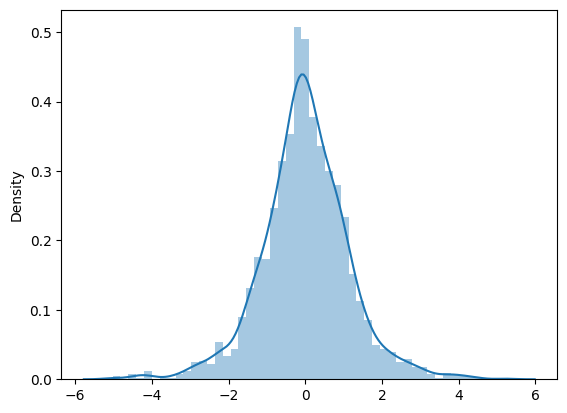

C:\Users\DELL\AppData\Local\Temp\ipykernel_13820\3699403474.py:16: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test)  # Actual Mental health Score


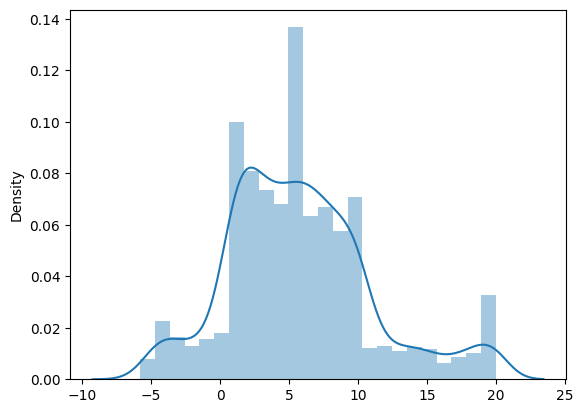

C:\Users\DELL\AppData\Local\Temp\ipykernel_13820\3699403474.py:19: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred) # Prediction Mental health Score


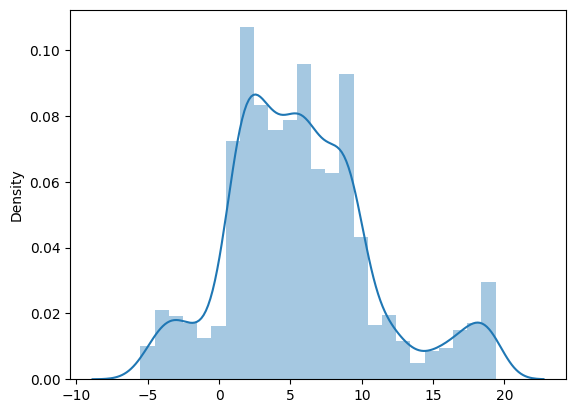

ValueError: Per-column arrays must each be 1-dimensional

In [136]:
evaluation_model(final_model,X_train,X_test,y_train,y_test)

In [142]:
y_test.shape,y_pred.shape

((500, 4), (500, 4))

In [141]:
# sns.scatterplot(x=y_test,y=y_pred[0])
# plt.show()

# 🔬 SHAP Explainability

Why did model predict:

High Depression Risk?

or

Wellness Score = 42?

In [144]:
!pip install shap

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -- ------------------------------------- 2.6/38.1 MB 13.4 MB/s eta 0:00:03
   ----- ---------------------------------- 5.5/38.1 MB 13.6 MB/s eta 0:00:03
   ---------- ----------------------------- 9.7/38.1 MB 15.7 MB/s eta 0:00:02
   --------------- ------------------------ 15.2/38.1 MB 18.5 MB/s eta 0:00:02
   --------------------- ------------------ 20.7/38.1 MB 20.3 MB/s eta 0:00:01
   --------------------------- ------------ 26.2/38.1 MB 21.2 MB/s eta 0:00:01
   ----------------------------- ---------- 27.8/38.1 MB 19.4 MB/s eta 0:00:01
   ------------------------------- -------- 29.9/38.1 MB 18.3 MB/s eta 0:00:01
   --------------------------------- ------ 32.0/38.1 MB 17.2 MB/s eta 0:00:01
   ---------------------------------- ----- 33.0/38.1 MB 16.0 MB/s eta 0:00:01
   ------------------------------------- -- 35.4/38.1 MB 15.5 MB/s eta 0:00:01
   ---------------------------------------  37.5/38.1 MB 15.2 MB


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [145]:
import shap

for name, model in models.items():

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    print(explainer) 
    print(shap_values)
    



C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


InvalidModelError: Model type not yet supported by TreeExplainer: <class 'sklearn.multioutput.MultiOutputRegressor'>

In [146]:
# Save Model 
import joblib
joblib.dump(final_model,"final_model.pkl")

['final_model.pkl']

In [147]:
load = joblib.load("final_model.pkl")
load.predict(X_test)

array([[ 7.3633924 ,  7.1208344 , -0.1800498 , 14.569862  ],
       [ 9.6887245 ,  9.083535  , -3.3941624 , 18.79634   ],
       [ 8.654062  ,  8.037695  , -0.6444689 , 16.683893  ],
       ...,
       [ 5.8819995 ,  5.2987356 ,  0.89882386, 11.077269  ],
       [ 9.006092  ,  8.4896755 , -3.620012  , 17.488596  ],
       [ 9.113338  ,  8.472979  , -2.841698  , 17.658457  ]],
      dtype=float32)